# Session 11 - Workshop: Build a Bias Audit Report

**Research Methods & Scientific Integrity in AI** - Doctoral Program in Deep Technologies, UNMSM
**Instructor:** Dr. Loveleen Gaur

### Your deliverable (due Wednesday, via the course platform)
A **Bias Audit Report** with *before* and *after* metrics. By the end of this notebook you will have:

1. A baseline model and its fairness numbers
2. One mitigation applied, with the numbers re-measured
3. A before / after table, an uncertainty check, and a short written analysis naming the trade-off

The notebook has been completed and executed top to bottom. All required decisions and outputs are retained.

> **Datasets.** The default is **COMPAS** (recidivism). You can switch the protected attribute to `sex` in the config cell, or switch to **Adult Census** (income) using the loader in Section 10. Pick the one closer to your own research.

> **A warning you should read before you start.** The single most common error in a fairness audit is not a coding error. It is getting the *direction of the favorable outcome* backwards. If you do that, every metric in your report keeps its magnitude, reverses its meaning, and still looks completely professional. Section 3 makes you state the direction out loud and then asserts it in code.

## 1. Setup

In [1]:
# --- One-time setup (Colab): install the fairness toolkits ---
# AIF360 = IBM AI Fairness 360.  Fairlearn = Microsoft's fairness library.
# The pandas pin matters: AIF360's StandardDataset crashes on the pandas 3 string dtype
# with "TypeError: Cannot interpret '<StringDtype...>' as a data type".
# Dependencies installed in an isolated environment: aif360, fairlearn, pandas<3

import warnings, os, urllib.request, numpy as np, pandas as pd
import matplotlib.pyplot as plt
def display(value):
    print(value.to_string() if hasattr(value, 'to_string') else value)
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from aif360.datasets import CompasDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import aif360, fairlearn, sklearn
print("aif360", aif360.__version__, "| fairlearn", fairlearn.__version__, "| pandas", pd.__version__, "| sklearn", sklearn.__version__)

aif360 0.6.1 | fairlearn 0.14.0 | pandas 2.3.3 | sklearn 1.9.0


pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


In [2]:
# --- Fetch the COMPAS data that AIF360 expects (not bundled, for licensing reasons) ---
import aif360
compas_dir = os.path.join(os.path.dirname(aif360.__file__), "data", "raw", "compas")
os.makedirs(compas_dir, exist_ok=True)
csv_path = os.path.join(compas_dir, "compas-scores-two-years.csv")
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

if not os.path.exists(csv_path) or os.path.getsize(csv_path) < 1_000_000:
    urllib.request.urlretrieve(url, csv_path)

size = os.path.getsize(csv_path)
assert size > 1_000_000, f"COMPAS download looks truncated ({size} bytes). Re-run this cell."
print(f"COMPAS data present ({size:,} bytes).")

COMPAS data present (2,546,489 bytes).


## 2. Config and audit helpers

One config cell drives the whole notebook, so you can re-run everything for a different protected attribute by editing a single line.

In [3]:
# ============ CONFIG: edit this, then Runtime > Run all ============
PROTECTED = "race"          # "race" or "sex"
TEST_FRACTION = 0.30
# ==================================================================

# AIF360 encodes COMPAS as: race 1 = Caucasian, 0 = African-American
#                           sex  1 = Female,    0 = Male     <-- note the flip, do not assume
GROUP_LABELS = {
    "race": {1: "Caucasian (privileged)", 0: "African-American (unprivileged)"},
    "sex":  {1: "Female (privileged)",    0: "Male (unprivileged)"},
}
privileged_groups   = [{PROTECTED: 1}]
unprivileged_groups = [{PROTECTED: 0}]
print("Auditing:", PROTECTED, "->", GROUP_LABELS[PROTECTED])

Auditing: race -> {1: 'Caucasian (privileged)', 0: 'African-American (unprivileged)'}


In [4]:
# --- Helpers so BEFORE and AFTER are always measured the exact same way ---

def make_pred_dataset(base_dataset, model, X, favorable_label):
    """Wrap model output in an AIF360 dataset.

    Two things here are easy to get wrong and both matter:
      1. deepcopy=True. A shallow copy shares the .scores array with the source
         dataset, so post-processing methods would silently read the GROUND TRUTH
         instead of your model's probabilities.
      2. scores must be P(favorable), and the favorable class is not always column 1.
         For COMPAS the favorable label is 0, so we look up the right column.
    """
    fav_col = list(model.classes_).index(favorable_label)
    out = base_dataset.copy(deepcopy=True)
    out.labels = model.predict(X).reshape(-1, 1)
    out.scores = model.predict_proba(X)[:, fav_col].reshape(-1, 1)
    return out

def audit(dataset_true, dataset_pred, unpriv, priv):
    """Return the fairness + accuracy numbers we care about for this session."""
    cm = ClassificationMetric(dataset_true, dataset_pred,
                              unprivileged_groups=unpriv, privileged_groups=priv)
    di = cm.disparate_impact()
    if not np.isfinite(di):
        print("WARNING: disparate impact is not finite. One group received zero "
              "favorable predictions. Report this rather than hiding it.")
    return {
        "Accuracy":                cm.accuracy(),
        "Disparate impact":        di,                                   # want 1.0 (>= 0.8)
        "Statistical parity diff": cm.statistical_parity_difference(),   # want 0
        "Equal opportunity diff":  cm.equal_opportunity_difference(),    # want 0
        "Average odds diff":       cm.average_odds_difference(),         # want 0
    }

def fourfifths_flag(di):
    """The 80% rule of thumb used by regulators (e.g. NYC Local Law 144)."""
    return "PASS (>= 0.8)" if di >= 0.8 else "FAIL (< 0.8): potential disparate impact"

def show(name, m):
    print(name)
    for k, v in m.items():
        print(f"  {k:26s}: {v: .3f}")
    print("  Four-fifths rule          :", fourfifths_flag(m["Disparate impact"]))

## 3. Load the data and pin down the direction of "favorable"

**Completed:** the favorable-outcome direction was verified and interpreted in the markdown cell below. Getting the direction right is half of a correct audit, and the assertion in the next cell exists because this is where audits go wrong.

In [5]:
dataset = CompasDataset()

train, test = dataset.split([1 - TEST_FRACTION], shuffle=True, seed=RANDOM_STATE)

FAV = dataset.favorable_label      # do NOT hard-code this to 1
UNFAV = dataset.unfavorable_label

print("Label column      :", dataset.label_names)
print("Favorable label   :", FAV)
print("Unfavorable label :", UNFAV)
print("Protected attrs   :", dataset.protected_attribute_names)
print("Train / test sizes:", train.features.shape[0], "/", test.features.shape[0])
print()

# The label column is two_year_recid: 1 = rearrested within two years, 0 = not.
# AIF360 therefore sets favorable_label = 0.  Being predicted NOT to re-offend is the
# outcome that leads to the better real-world consequence (release, lower bail).
assert FAV == 0.0, ("Expected the favorable label to be 0 (did NOT re-offend). "
                    "If this fires, the dataset encoding changed and every metric "
                    "below would silently reverse meaning.")
print("DIRECTION CONFIRMED")
print("  favorable  = label 0 = did NOT re-offend within two years = good for the defendant")
print("  unfavorable= label 1 = rearrested within two years")

Label column      : ['two_year_recid']
Favorable label   : 0.0
Unfavorable label : 1.0
Protected attrs   : ['sex', 'race']
Train / test sizes: 4316 / 1851

DIRECTION CONFIRMED
  favorable  = label 0 = did NOT re-offend within two years = good for the defendant
  unfavorable= label 1 = rearrested within two years


**Completed interpretation**

- Protected attribute I am auditing: `race`
- Privileged group: `Caucasian` | Unprivileged group: `African-American`
- The favorable outcome means that the person was **not rearrested within two years**.
- If this direction were reversed, the report would incorrectly treat rearrest as a beneficial selection outcome and invert the ethical interpretation of the fairness metrics.


## 4. Measure bias in the raw data

This looks only at the ground-truth labels. No model exists yet, so anything you find here is measured historical inequality, not a modelling artifact. It is also the ceiling problem for everything that follows: you are about to ask a classifier to be fairer than the data it learns from.

In [6]:
raw = BinaryLabelDatasetMetric(train,
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups)
print(f"Disparate impact (data):        {raw.disparate_impact():.3f}")
print(f"Statistical parity diff (data): {raw.mean_difference():.3f}")
print(f"Base rate, unprivileged:        {raw.base_rate(privileged=False):.3f}")
print(f"Base rate, privileged:          {raw.base_rate(privileged=True):.3f}")

Disparate impact (data):        0.850
Statistical parity diff (data): -0.090
Base rate, unprivileged:        0.510
Base rate, privileged:          0.600


## 5. Look at what you are actually feeding the model

Two facts about AIF360's default COMPAS feature set are worth a minute of class discussion before you train anything.

In [7]:
feat = dataset.feature_names
print("Number of features:", len(feat))
print()
print("1) Is the protected attribute itself an input feature?")
for p in dataset.protected_attribute_names:
    print(f"   {p:5s} in features: {p in feat}")
print()
print("2) Where do all these features come from?")
charge_desc = [f for f in feat if f.startswith("c_charge_desc=")]
print(f"   c_charge_desc is one-hot encoded into {len(charge_desc)} columns,")
print(f"   leaving only {len(feat) - len(charge_desc)} substantive features.")
print()
print("Discussion:")
print("  - The model below trains ON race. Deleting it would not fix anything:")
print("    priors_count and charge degree are strong proxies. 'Fairness through")
print("    unawareness' is not a mitigation, it is a way of not seeing the problem.")
print("  - A high-dimensional sparse one-hot block invites overfitting. Try setting")
print("    features_to_drop=['c_charge_desc'] in CompasDataset() and see what moves.")

Number of features: 401

1) Is the protected attribute itself an input feature?
   sex   in features: True
   race  in features: True

2) Where do all these features come from?
   c_charge_desc is one-hot encoded into 389 columns,
   leaving only 12 substantive features.

Discussion:
  - The model below trains ON race. Deleting it would not fix anything:
    priors_count and charge degree are strong proxies. 'Fairness through
    unawareness' is not a mitigation, it is a way of not seeing the problem.
  - A high-dimensional sparse one-hot block invites overfitting. Try setting
    features_to_drop=['c_charge_desc'] in CompasDataset() and see what moves.


## 6. Train your baseline model

**Completed:** a `LogisticRegression` was fitted on the scaled training features and evaluated on the held-out test set.

In [8]:
scaler  = StandardScaler().fit(train.features)
X_train = scaler.transform(train.features)
X_test  = scaler.transform(test.features)
y_train = train.labels.ravel()

# Completed 1: create and fit the baseline classifier
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

# Completed 2: wrap predictions into AIF360 datasets (helper handles scores + deepcopy)
train_pred = make_pred_dataset(train, baseline, X_train, FAV)
test_pred  = make_pred_dataset(test,  baseline, X_test,  FAV)

before = audit(test, test_pred, unprivileged_groups, privileged_groups)
show("BEFORE mitigation", before)

BEFORE mitigation
  Accuracy                  :  0.664
  Disparate impact          :  0.773
  Statistical parity diff   : -0.165
  Equal opportunity diff    : -0.095
  Average odds diff         : -0.139
  Four-fifths rule          : FAIL (< 0.8): potential disparate impact


## 7. Choose and apply ONE mitigation

Three families, one runnable option each. Every option below is **self-contained**: you can run any one of them without having run the others.

| Family | Option | Acts on | Targets |
|---|---|---|---|
| Pre-processing | A. Reweighing | training data | statistical parity / disparate impact |
| In-processing | B. Exponentiated Gradient | the learning objective | whichever constraint you pass |
| Post-processing | C. Reject Option Classification | the predictions | statistical parity, near the decision boundary |

**Completed:** Option A, Reweighing, was selected and executed; the rationale and target metric are stated below.

**Selected option:** A. Reweighing (pre-processing). It was selected because it is deterministic, retains the original features and labels, and directly changes training weights to reduce dependence between protected group and favorable outcome. It primarily targets statistical parity/disparate impact; it does not guarantee equalized odds, calibration, or individual fairness.


In [9]:
# --- Option A (default): Reweighing, a PRE-processing method ---
# Weights each training row by (expected count under group-label independence) / (observed count).
# Features and labels are never altered; the weights go into sklearn via sample_weight.
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
train_rw = RW.fit_transform(train)

mitigated = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
mitigated.fit(X_train, y_train, sample_weight=train_rw.instance_weights)

test_pred_mit = make_pred_dataset(test, mitigated, X_test, FAV)

after = audit(test, test_pred_mit, unprivileged_groups, privileged_groups)
show("AFTER mitigation (Reweighing)", after)

AFTER mitigation (Reweighing)
  Accuracy                  :  0.653
  Disparate impact          :  0.975
  Statistical parity diff   : -0.016
  Equal opportunity diff    :  0.031
  Average odds diff         :  0.015
  Four-fifths rule          : PASS (>= 0.8)


In [10]:
# --- Option B: IN-processing with Fairlearn ExponentiatedGradient ---
# Uncomment the block to use this instead of Option A. It overwrites `after`.
# Note: this returns a RANDOMIZED ensemble, so predictions vary run to run unless seeded,
# and it has no predict_proba, so we set scores from the hard labels.
#
# from fairlearn.reductions import ExponentiatedGradient, DemographicParity
#
# sens_train = train.protected_attributes[:, train.protected_attribute_names.index(PROTECTED)]
# eg = ExponentiatedGradient(
#         LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
#         constraints=DemographicParity())
# eg.fit(X_train, y_train, sensitive_features=sens_train)
#
# test_pred_mit = test.copy(deepcopy=True)
# test_pred_mit.labels = eg.predict(X_test, random_state=RANDOM_STATE).reshape(-1, 1)
# test_pred_mit.scores = (test_pred_mit.labels == FAV).astype(float)
#
# after = audit(test, test_pred_mit, unprivileged_groups, privileged_groups)
# show("AFTER mitigation (Exponentiated Gradient)", after)

In [11]:
# --- Option C: POST-processing with Reject Option Classification ---
# Uncomment the block to use this instead of Option A. It overwrites `after`.
# This one only works because make_pred_dataset() put real P(favorable) into .scores.
# If scores were left aliased to the ground truth, this would leak the labels and you
# would get an impossibly good result.
#
# from aif360.algorithms.postprocessing import RejectOptionClassification
#
# roc = RejectOptionClassification(
#         unprivileged_groups=unprivileged_groups,
#         privileged_groups=privileged_groups,
#         low_class_thresh=0.01, high_class_thresh=0.99,
#         num_class_thresh=100, num_ROC_margin=50,
#         metric_name="Statistical parity difference",
#         metric_ub=0.05, metric_lb=-0.05)
# roc = roc.fit(train, train_pred)          # fit on TRAIN predictions, never on test
# test_pred_mit = roc.predict(test_pred)
#
# after = audit(test, test_pred_mit, unprivileged_groups, privileged_groups)
# show("AFTER mitigation (Reject Option Classification)", after)

## 8. Compare before vs after, and price the trade-off

This is the heart of the deliverable. A report that claims a fairness gain at *zero* cost usually did not measure carefully.

In [12]:
compare = pd.DataFrame({"Before": before, "After": after})
compare["Change"] = compare["After"] - compare["Before"]
display(compare.round(3))

acc_cost = before["Accuracy"] - after["Accuracy"]
di_gain  = after["Disparate impact"] - before["Disparate impact"]
print(f"Disparate impact moved {di_gain:+.3f} toward parity (1.0 is parity).")
print(f"Accuracy changed {(-acc_cost):+.3f}.")
print(f"Four-fifths rule: {fourfifths_flag(before['Disparate impact'])}"
      f"  ->  {fourfifths_flag(after['Disparate impact'])}")
print()

# Did any gap OVERSHOOT past zero? Reporting a sign flip as a clean win is dishonest.
for k in ["Statistical parity diff", "Equal opportunity diff", "Average odds diff"]:
    if np.sign(before[k]) != np.sign(after[k]) and abs(after[k]) > 1e-9:
        print(f"NOTE: {k} crossed zero ({before[k]:+.3f} -> {after[k]:+.3f}). "
              f"The mitigation overcorrected. Say so in your report.")

                         Before  After  Change
Accuracy                  0.664  0.653  -0.011
Disparate impact          0.773  0.975   0.202
Statistical parity diff  -0.165 -0.016   0.149
Equal opportunity diff   -0.095  0.031   0.125
Average odds diff        -0.139  0.015   0.154
Disparate impact moved +0.202 toward parity (1.0 is parity).
Accuracy changed -0.011.
Four-fifths rule: FAIL (< 0.8): potential disparate impact  ->  PASS (>= 0.8)

NOTE: Equal opportunity diff crossed zero (-0.095 -> +0.031). The mitigation overcorrected. Say so in your report.
NOTE: Average odds diff crossed zero (-0.139 -> +0.015). The mitigation overcorrected. Say so in your report.


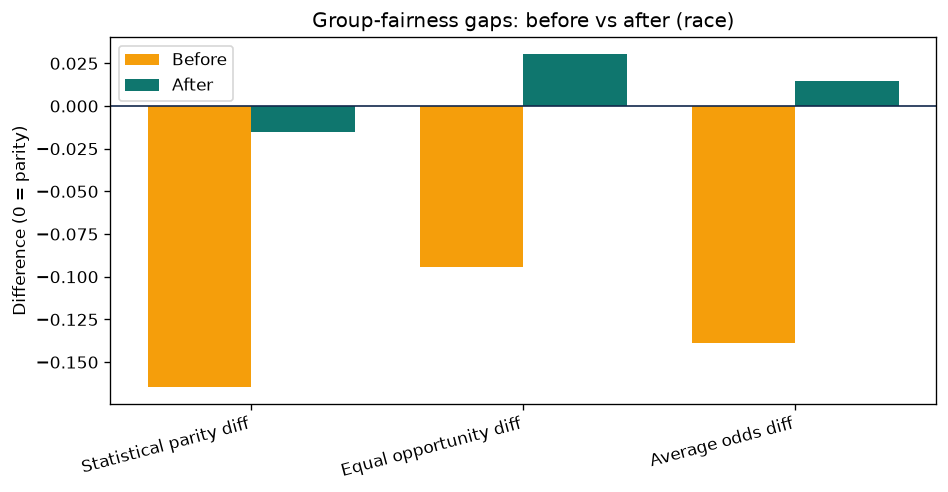

In [13]:
# Before/after chart for your report (right-click the image to save it)
labels = ["Statistical parity diff", "Equal opportunity diff", "Average odds diff"]
b = [before[k] for k in labels]; a = [after[k] for k in labels]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x - w/2, b, w, label="Before", color="#F59E0B")
ax.bar(x + w/2, a, w, label="After",  color="#0F766E")
ax.axhline(0, color="#12284B", lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Difference (0 = parity)")
ax.set_title(f"Group-fairness gaps: before vs after ({PROTECTED})")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Is the change real, or is it noise?

Every number so far is a point estimate from **one** train/test split. Before you write "fairness improved" in a doctoral submission, check whether the improvement survives resampling. This cell repeats the whole pipeline across several splits and reports mean and standard deviation.

If a gap's mean is smaller than its standard deviation, you do not have a finding. You have noise.

In [14]:
N_SPLITS = 10
rows = []
for s in range(N_SPLITS):
    tr, te = dataset.split([1 - TEST_FRACTION], shuffle=True, seed=s)
    sc = StandardScaler().fit(tr.features)
    Xtr, Xte = sc.transform(tr.features), sc.transform(te.features)
    ytr = tr.labels.ravel()

    b_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xtr, ytr)
    b_m = audit(te, make_pred_dataset(te, b_clf, Xte, FAV),
                unprivileged_groups, privileged_groups)

    w = Reweighing(unprivileged_groups=unprivileged_groups,
                   privileged_groups=privileged_groups).fit_transform(tr)
    a_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    a_clf.fit(Xtr, ytr, sample_weight=w.instance_weights)
    a_m = audit(te, make_pred_dataset(te, a_clf, Xte, FAV),
                unprivileged_groups, privileged_groups)

    rows.append({"seed": s, **{f"before_{k}": v for k, v in b_m.items()},
                             **{f"after_{k}":  v for k, v in a_m.items()}})

res = pd.DataFrame(rows)
summary = pd.DataFrame({
    "Before mean": [res[f"before_{k}"].mean() for k in before],
    "Before sd":   [res[f"before_{k}"].std()  for k in before],
    "After mean":  [res[f"after_{k}"].mean()  for k in before],
    "After sd":    [res[f"after_{k}"].std()   for k in before],
}, index=list(before))
summary["Mean change"] = summary["After mean"] - summary["Before mean"]
display(summary.round(3))

print(f"Across {N_SPLITS} splits:")
for k in ["Disparate impact", "Accuracy", "Equal opportunity diff"]:
    mc, sd = summary.loc[k, "Mean change"], res[f"after_{k}"].std()
    verdict = "robust" if abs(mc) > 2 * sd else "NOT distinguishable from noise"
    print(f"  {k:24s} mean change {mc:+.3f}, after-sd {sd:.3f}  ->  {verdict}")

                         Before mean  Before sd  After mean  After sd  Mean change
Accuracy                       0.671      0.013       0.665     0.012       -0.006
Disparate impact               0.775      0.032       1.000     0.063        0.225
Statistical parity diff       -0.161      0.027      -0.001     0.039        0.159
Equal opportunity diff        -0.091      0.029       0.053     0.030        0.144
Average odds diff             -0.140      0.024       0.021     0.036        0.162
Across 10 splits:
  Disparate impact         mean change +0.225, after-sd 0.063  ->  robust
  Accuracy                 mean change -0.006, after-sd 0.012  ->  NOT distinguishable from noise
  Equal opportunity diff   mean change +0.144, after-sd 0.030  ->  robust


## 10. Cross-check with Fairlearn, and the trap inside it

Using a second library to confirm a headline number is good scientific hygiene. But you cannot just hand your labels to Fairlearn and expect the same answer.

**Fairlearn treats label `1` as "selected".** In COMPAS the favorable label is `0`. So a naive call measures parity on the *unfavorable* outcome. You get away with it for the *difference* (it is symmetric up to sign, and Fairlearn returns max-minus-min so the sign is discarded), but the *ratio* comes out wrong and will not match AIF360's disparate impact. The cell below shows both, deliberately.

In [15]:
from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
                                demographic_parity_ratio)
from sklearn.metrics import accuracy_score

sens_test = test.protected_attributes[:, test.protected_attribute_names.index(PROTECTED)]
y_true = test.labels.ravel()
y_hat  = test_pred_mit.labels.ravel()

# Recode so that 1 = favorable, which is what Fairlearn assumes.
y_true_f = (y_true == FAV).astype(int)
y_hat_f  = (y_hat  == FAV).astype(int)

print("AIF360 (after)      : DI = %.3f | SPD = %+.3f"
      % (after["Disparate impact"], after["Statistical parity diff"]))
print()
print("Fairlearn, NAIVE (label 1 treated as selected)  <-- WRONG for this dataset")
print("  DP difference: %.3f" % demographic_parity_difference(y_true, y_hat, sensitive_features=sens_test))
print("  DP ratio     : %.3f   (does not match AIF360's DI)"
      % demographic_parity_ratio(y_true, y_hat, sensitive_features=sens_test))
print()
print("Fairlearn, CORRECTED (favorable recoded to 1)")
print("  DP difference: %.3f" % demographic_parity_difference(y_true_f, y_hat_f, sensitive_features=sens_test))
print("  DP ratio     : %.3f   (matches AIF360's DI)"
      % demographic_parity_ratio(y_true_f, y_hat_f, sensitive_features=sens_test))
print()

mf = MetricFrame(metrics=accuracy_score, y_true=y_true, y_pred=y_hat,
                 sensitive_features=sens_test)
print("Accuracy by group (did one group pay for the fairness gain?):")
print(mf.by_group.round(3).to_string())

AIF360 (after)      : DI = 0.975 | SPD = -0.016

Fairlearn, NAIVE (label 1 treated as selected)  <-- WRONG for this dataset
  DP difference: 0.016
  DP ratio     : 0.960   (does not match AIF360's DI)

Fairlearn, CORRECTED (favorable recoded to 1)
  DP difference: 0.016
  DP ratio     : 0.975   (matches AIF360's DI)

Accuracy by group (did one group pay for the fairness gain?):
sensitive_feature_0
0.0    0.651
1.0    0.656


## 11. (Alternative dataset) Adult Census income

Only run this if you chose Adult instead of COMPAS. Note that the favorable label here is `1` (income > 50K), the **opposite** of COMPAS, which is exactly why Section 3 asserts the direction instead of assuming it.

The cell tries Fairlearn's OpenML loader first because UCI's own endpoint is unreliable. If both fail you will get a clear message rather than a silent wrong answer.

In [16]:
# Optional Adult Census branch intentionally skipped.
print("Skipped optional Adult Census section: COMPAS/race was selected for this audit.")


Skipped optional Adult Census section: COMPAS/race was selected for this audit.


## 12. Completed Bias Audit Report

The full interpretation, uncertainty assessment, statistical fallacy scan, limitations, and recommendation are in [`bias_audit_report.md`](bias_audit_report.md).

### Audit configuration

- Dataset: COMPAS
- Protected attribute: race
- Privileged / unprivileged groups: Caucasian / African-American
- Favorable outcome: label 0, not rearrested within two years
- Baseline: standardized logistic regression
- Mitigation: AIF360 Reweighing (pre-processing)

### Before and after

| Metric | Before | After | Change |
|---|---:|---:|---:|
| Accuracy | 0.664 | 0.653 | -0.011 |
| Disparate impact | 0.773 | 0.975 | +0.202 |
| Statistical parity difference | -0.165 | -0.016 | +0.149 |
| Equal opportunity difference | -0.095 | +0.031 | +0.125 |
| Average odds difference | -0.139 | +0.015 | +0.154 |

Reweighing moved selection-rate metrics closer to parity at a 1.1 percentage-point accuracy cost in the primary split. Equal opportunity and average odds crossed zero, indicating slight overcorrection rather than a universally fair result.

Across ten splits, the mean DI change was +0.225 (after SD 0.063), while mean accuracy change was -0.006 (after SD 0.012). This is a descriptive stability check, not a formal significance test.

### Recommendation and limitation

Do not deploy based on this audit. Next steps require intersectional groups, calibration and error-rate analysis, alternative mitigations and thresholds, label-validity review, and human contestability. This COMPAS exercise is independent of MEDISEG and does not establish fairness for AI-DOTS.
